### Mathematical Formulation
Let the raw tick stream be defined as a sequence of tuples $\{(p_i, v_i)\}_{i=1}^N$, representing the price and volume of the $i$-th transaction. We define the $k$-th bar as containing the sequence of ticks $i \in [T_{k-1} + 1, T_k]$.The index $T_k$ is determined by an arbitrary threshold $\theta$:Tick Bars: Sample when a fixed number of transactions have occurred.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t 1 \geq \theta_T \right\}$$Volume Bars: Sample when a fixed number of shares/contracts have been traded.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t v_i \geq \theta_V \right\}$$Dollar Bars: Sample when a fixed fiat value has been exchanged. This is generally the most robust of the three, as it naturally adjusts for significant price changes, stock splits, and inflation.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t p_i v_i \geq \theta_D \right\}$$

In [1]:
import pandas as pd


def load_data_from_csv(csv_file: str) -> pd.DataFrame:
    # yfinance CSV export uses a 2-row header for MultiIndex columns and a standalone index-name row.
    # data = pd.read_csv(csv_file, header=[0, 1], skiprows=[2], index_col=0)

    # data.index = pd.to_datetime(data.index)
    # data.index.name = "timestamp"
    df = pd.read_csv(csv_file, parse_dates=['timestamp'])
    df.sort_values('timestamp', inplace=True)

    return df


output_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_1Min.csv"

df = load_data_from_csv(output_file)

OSError: [Errno 22] Invalid argument

In [4]:
#Use a subset
# df = df[df['timestamp'] < '2022-01-01']

Standard bars sample the market based on the total magnitude of activity, indiscriminately grouping buyer-initiated and seller-initiated flow.Tick Threshold ($\theta_T$): Measures algorithmic fragmentation.$$\theta_{T, t+1} = \frac{\mathbb{E}[\text{Trades}_t]}{E[N]}$$Trigger: Accumulator breaches $\theta_T$.Volume Threshold ($\theta_V$): Measures share turnover.$$\theta_{V, t+1} = \frac{\mathbb{E}[V_t]}{E[N]}$$Trigger: Accumulator breaches $\theta_V$.Dollar Threshold ($\theta_D$): Measures fiat capital commitment (Risk Transfer). This is the most stable standard metric.$$\theta_{D, t+1} = \frac{\mathbb{E}[P_t \cdot V_t]}{E[N]}$$Trigger: Accumulator breaches $\theta_D$.B. The Imbalance Threshold ($\tau_D$)While standard bars seek to stabilize variance, Imbalance Bars seek to extract directional features by identifying toxic, one-sided order flow. They accumulate signed volume based on the Tick Rule ($b_i \in \{1, -1\}$).You cannot use the standard dollar threshold ($\theta_D$) for imbalance bars because the expected net imbalance is vastly smaller than the expected total volume. The imbalance threshold $\tau_D$ is derived by scaling the standard dollar threshold by the Expected Flow Asymmetry.Let $P[b=1]$ be the probability of an uptick. The expected tick sign $\mathbb{E}[b]$ is:$$\mathbb{E}[b] = P[b=1](1) + (1 - P[b=1])(-1) = 2P[b=1] - 1$$The final Dollar Imbalance Threshold is therefore:$$\tau_{D, t+1} = \theta_{D, t+1} \cdot |2P[b_{t}=1] - 1|$$

In [56]:
import pandas as pd
import numpy as np


def compute_comparative_thresholds(
    df: pd.DataFrame,
    target_bars: int = 24,
    window: int = 21,
) -> pd.DataFrame:
    """
    Computes daily dynamic thresholds using Prado's exact conditional 
    expectation formulation for Imbalance Bars.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["date"] = df["timestamp"].dt.date
    df["dollar_volume"] = df["volume"] * df["vwap"]

    # ------------------------------------------------------------------
    # 1. Pseudo-tick sign sequence
    # ------------------------------------------------------------------
    df["dp"] = df.groupby("date")["vwap"].transform(lambda s: s.diff())
    df["sign"] = np.sign(df["dp"])
    df["sign"] = df["sign"].replace(0, np.nan).ffill().fillna(1.0)
    
    # ------------------------------------------------------------------
    # 2. Partition volume by tick sign
    # ------------------------------------------------------------------
    df["is_uptick"] = (df["sign"] == 1.0).astype(int)
    df["is_downtick"] = (df["sign"] == -1.0).astype(int)
    
    # Isolate the dollar volume corresponding to up and down moves
    df["dollar_up"] = df["dollar_volume"] * df["is_uptick"]
    df["dollar_down"] = df["dollar_volume"] * df["is_downtick"]
    print(df["dollar_down"].sample(5))

    # ------------------------------------------------------------------
    # 3. Daily aggregation
    # ------------------------------------------------------------------
    daily_stats = df.groupby("date").agg(
        daily_ticks=("trade_count", "sum"),
        daily_volume=("volume", "sum"),
        daily_dollar=("dollar_volume", "sum"),
        total_rows=("vwap", "count"),        
        total_upticks=("is_uptick", "sum"),
        total_downticks=("is_downtick", "sum"),
        dollar_up=("dollar_up", "sum"),
        dollar_down=("dollar_down", "sum")
    )

    # ------------------------------------------------------------------
    # 4. Out-of-sample EWMA expectations
    # ------------------------------------------------------------------
    ewm_kwargs = dict(span=window, min_periods=window, adjust=False)
    expected_stats = daily_stats.ewm(**ewm_kwargs).mean().shift(1)

    # ------------------------------------------------------------------
    # 5. Standard thresholds
    # ------------------------------------------------------------------
    daily_thresholds = pd.DataFrame(index=expected_stats.index)
    daily_thresholds["Tick_Threshold"]   = expected_stats["daily_ticks"]   / target_bars
    daily_thresholds["Volume_Threshold"] = expected_stats["daily_volume"]  / target_bars
    daily_thresholds["Dollar_Threshold"] = expected_stats["daily_dollar"]  / target_bars

    # ------------------------------------------------------------------
    # 6. Prado's Exact Imbalance Threshold Formulation
    # ------------------------------------------------------------------
    # Calculate Probabilities: P[b=1] and P[b=-1]
    p_up = expected_stats["total_upticks"] / expected_stats["total_rows"]
    p_down = expected_stats["total_downticks"] / expected_stats["total_rows"]

    # Calculate Conditional Expectations: E[v | b=1] and E[v | b=-1]
    # .replace(0, np.nan) prevents ZeroDivisionError if an extreme regime 
    # results in an expected count of exactly 0.
    e_v_up = expected_stats["dollar_up"] / expected_stats["total_upticks"].replace(0, np.nan)
    e_v_down = expected_stats["dollar_down"] / expected_stats["total_downticks"].replace(0, np.nan)

    # Expected absolute imbalance per tick
    expected_imbalance_per_tick = (p_up * e_v_up - p_down * e_v_down).abs()

    # E[T] = Expected ticks per bar
    e_t_per_bar = expected_stats["total_rows"] / target_bars

    # Final threshold: Tau = E[T] * | P[b=1]E[v|b=1] - P[b=-1]E[v|b=-1] |
    # Bounded to 0.01 to prevent the zero-threshold infinite loop failure mode.
    daily_thresholds["Imbalance_Threshold"] = (e_t_per_bar * expected_imbalance_per_tick).clip(lower=0.01)

    return daily_thresholds.dropna()
# Example Usage:
window = 5
dynamic_thresholds_df = compute_comparative_thresholds(df, target_bars=1, window= window)
# print(dynamic_thresholds_df.head())

#Print random thresholds
print(dynamic_thresholds_df.sample(5))

1957827    1.181025e+08
395049     8.114928e+07
1479945    0.000000e+00
1748952    0.000000e+00
736659     0.000000e+00
Name: dollar_down, dtype: float64
            Tick_Threshold  Volume_Threshold  Dollar_Threshold  \
date                                                             
2016-08-19    2.090867e+05      6.157935e+07      1.344437e+10   
2017-05-03    1.964377e+05      6.948361e+07      1.655019e+10   
2016-07-13    3.476044e+05      1.048843e+08      2.223157e+10   
2023-03-15    1.067178e+06      1.411966e+08      5.514315e+10   
2024-07-02    3.823696e+05      4.829338e+07      2.633250e+10   

            Imbalance_Threshold  
date                             
2016-08-19         7.323908e+07  
2017-05-03         9.765107e+08  
2016-07-13         2.524913e+09  
2023-03-15         6.751534e+08  
2024-07-02         2.066189e+08  


In [43]:
mean_tick = (df['trade_count']).mean()
print(f"Mean Tick Count: {mean_tick:.2e}")
max_tick = (df['trade_count']).max()
print(f"Max Tick: {max_tick:.2e}")
mean_threshold = dynamic_thresholds_df['Tick_Threshold'].mean()
print(f"Mean Tick Threshold: {mean_threshold:.2e}")
max_threshold = dynamic_thresholds_df['Tick_Threshold'].max()
print(f"Max Tick Threshold: {max_threshold:.2e}")

Mean Tick Count: 6.33e+02
Max Tick: 6.48e+04
Mean Tick Threshold: 4.88e+05
Max Tick Threshold: 2.78e+06


In [44]:
mean_volume = (df['volume']).mean()
print(f"Mean Volume: {mean_volume:.2e}")
max_volume = (df['volume']).max()
print(f"Max Volume: {max_volume:.2e}")
mean_threshold = dynamic_thresholds_df['Volume_Threshold'].mean()
print(f"Mean Volume Threshold: {mean_threshold:.2e}")
max_threshold = dynamic_thresholds_df['Volume_Threshold'].max()
print(f"Max Volume Threshold: {max_threshold:.2e}")

Mean Volume: 1.06e+05
Max Volume: 3.40e+07
Mean Volume Threshold: 8.17e+07
Max Volume Threshold: 3.21e+08


In [45]:
# mean_volume = df['volume'].mean()
# print(f"Mean Volume: {mean_volume}")
# mean_price = df['vwap'].mean()
# print(f"Mean Price: {mean_price}")
# mean_tick = df['trade_count'].mean()
# print(f"Mean Tick Count: {mean_tick}")

# max_volume = df['volume'].max()
# print(f"Max Volume: {max_volume}")
# max_price = df['vwap'].max()
# print(f"Max Price: {max_price}")

mean_dollar_volume = (df['volume'] * df['vwap']).mean()
print(f"Mean Dollar Volume: {mean_dollar_volume:.2e}")
max_dollar_volume = (df['volume'] * df['vwap']).max()
print(f"Max Dollar Volume: {max_dollar_volume:.2e}")
mean_threshold = dynamic_thresholds_df['Dollar_Threshold'].mean()
print(f"Mean Dollar Threshold: {mean_threshold:.2e}")
max_threshold = dynamic_thresholds_df['Dollar_Threshold'].max()
print(f"Max Dollar Threshold: {max_threshold:.2e}")

Mean Dollar Volume: 3.80e+07
Max Dollar Volume: 9.35e+09
Mean Dollar Threshold: 2.93e+10
Max Dollar Threshold: 1.01e+11


In [46]:
import numpy as np
import pandas as pd

def form_bars(
    df: pd.DataFrame, 
    bar_type: str, 
    dynamic_thresholds_df: pd.DataFrame, 
    ewma_window: int = 100
) -> pd.DataFrame:
    """
    Forms standard or imbalance bars using Prado's exact conditional 
    expectation formulation via an autonomous event-driven state machine.
    """
    _EMPTY = pd.DataFrame(columns=['Open', 'High', 'Low', 'Close', 'Volume', 'VWAP'])

    # ------------------------------------------------------------------
    # 1. Resolve bar type & Identify the Seed Metric
    # ------------------------------------------------------------------
    bt = bar_type.strip().lower()
    is_imbalance = 'imbalance' in bt

    if is_imbalance:
        base_metric = 'dollar'
        seed_col = 'Dollar_Threshold'
    else:
        if bt not in {'tick', 'volume', 'dollar'}:
            raise ValueError("bar_type must be one of: 'tick', 'volume', 'dollar', 'imbalance'")
        base_metric = bt
        seed_col = f"{base_metric.capitalize()}_Threshold"

    if seed_col not in dynamic_thresholds_df.columns:
        raise KeyError(f"Column '{seed_col}' not found in dynamic_thresholds_df")

    # ------------------------------------------------------------------
    # 2. Extract Seed & Quarantine Burn-in
    # ------------------------------------------------------------------
    dates = pd.to_datetime(df['timestamp']).dt.date
    mapped_seeds = dates.map(dynamic_thresholds_df[seed_col]).ffill()

    valid_mask = mapped_seeds.notna()
    if not valid_mask.any(): return _EMPTY

    df = df.loc[valid_mask].reset_index(drop=True)
    initial_expected_magnitude = mapped_seeds[valid_mask].iloc[0]

    # ------------------------------------------------------------------
    # 3. Extract raw arrays
    # ------------------------------------------------------------------
    times       = df['timestamp'].values
    opens       = df['open'].values.astype(float)
    highs       = df['high'].values.astype(float)
    lows        = df['low'].values.astype(float)
    closes      = df['close'].values.astype(float)
    volumes     = df['volume'].values.astype(float)
    trade_counts = df['trade_count'].values.astype(float)
    vwaps       = df['vwap'].values.astype(float)

    n = len(volumes)
    if n == 0: return _EMPTY

    # ------------------------------------------------------------------
    # 4. Driving variable magnitude
    # ------------------------------------------------------------------
    if base_metric == 'tick':
        magnitudes = trade_counts
    elif base_metric == 'volume':
        magnitudes = volumes
    else:  
        magnitudes = vwaps * volumes

    # ------------------------------------------------------------------
    # 5. Vectorized tick rule (imbalance bars only)
    # ------------------------------------------------------------------
    if is_imbalance:
        dp = np.empty(n)
        dp[0] = np.nan
        dp[1:] = vwaps[1:] - vwaps[:-1]

        raw_signs = np.sign(dp)
        sign_series = pd.Series(np.where(raw_signs == 0, np.nan, raw_signs))
        b = sign_series.ffill().fillna(1.0).to_numpy()

        values = b * magnitudes
    else:
        values = magnitudes

    # ------------------------------------------------------------------
    # 6. Bar formation loop (Autonomous Event-Driven State Machine)
    # ------------------------------------------------------------------
    out_open  = np.empty(n)
    out_high  = np.empty(n)
    out_low   = np.empty(n)
    out_close = np.empty(n)
    out_vol   = np.empty(n)
    out_vwap  = np.empty(n)
    out_times = np.empty(n, dtype=times.dtype)

    cumulative_sum  = 0.0
    bar_idx         = 0
    current_high    = -np.inf
    current_low     =  np.inf
    current_open    = opens[0]
    current_vol     = 0.0
    current_dollar  = 0.0

    # Intraday Tracking for the CURRENT bar
    bar_actual_magnitude = 0.0
    bar_ticks            = 0.0
    bar_upticks          = 0.0
    bar_downticks        = 0.0
    bar_mag_up           = 0.0
    bar_mag_down         = 0.0

    # ------------------------------------------------------------------
    # Event-Driven EWMA States & Priors
    # ------------------------------------------------------------------
    alpha = 2.0 / (ewma_window + 1.0)
    
    expected_magnitude = initial_expected_magnitude

    if is_imbalance:
        # Initial priors to prevent cold-start division by zero
        expected_T_per_bar = 20.0 
        expected_p_up   = 0.5
        expected_p_down = 0.5
        expected_v_up   = expected_magnitude / expected_T_per_bar
        expected_v_down = expected_magnitude / expected_T_per_bar
        
        expected_imbalance_per_tick = abs(expected_p_up * expected_v_up - expected_p_down * expected_v_down)
        bar_threshold = expected_T_per_bar * expected_imbalance_per_tick
    else:
        bar_threshold = expected_magnitude

    for i in range(n):
        cumulative_sum       += values[i]
        bar_actual_magnitude += magnitudes[i]  
        bar_ticks            += 1.0
        
        # Partition the components by tick sign
        if is_imbalance:
            if b[i] == 1.0:
                bar_upticks += 1.0
                bar_mag_up  += magnitudes[i]
            else:
                bar_downticks += 1.0
                bar_mag_down  += magnitudes[i]

        current_vol    += volumes[i]
        current_dollar += vwaps[i] * volumes[i]

        if highs[i] > current_high: current_high = highs[i]
        if lows[i] < current_low:   current_low = lows[i]

        if is_imbalance:
            trigger = abs(cumulative_sum) >= bar_threshold
        else:
            trigger = cumulative_sum >= bar_threshold

        if trigger:
            out_open[bar_idx]  = current_open
            out_high[bar_idx]  = current_high
            out_low[bar_idx]   = current_low
            out_close[bar_idx] = closes[i]
            out_vol[bar_idx]   = current_vol
            out_vwap[bar_idx]  = (current_dollar / current_vol if current_vol > 0 else closes[i])
            out_times[bar_idx] = times[i]
            bar_idx += 1

            # --- Update Event-Driven Expectations ---
            if is_imbalance:
                # 1. Calculate actuals for the formed bar
                p_up   = bar_upticks / bar_ticks if bar_ticks > 0 else 0.5
                p_down = bar_downticks / bar_ticks if bar_ticks > 0 else 0.5
                
                # Conditional expectation of magnitude (only update if event occurred)
                v_up   = bar_mag_up / bar_upticks if bar_upticks > 0 else expected_v_up
                v_down = bar_mag_down / bar_downticks if bar_downticks > 0 else expected_v_down

                # 2. Update EWMAs
                expected_T_per_bar = (alpha * bar_ticks) + ((1.0 - alpha) * expected_T_per_bar)
                expected_p_up      = (alpha * p_up) + ((1.0 - alpha) * expected_p_up)
                expected_p_down    = (alpha * p_down) + ((1.0 - alpha) * expected_p_down)
                expected_v_up      = (alpha * v_up) + ((1.0 - alpha) * expected_v_up)
                expected_v_down    = (alpha * v_down) + ((1.0 - alpha) * expected_v_down)

                # 3. Compute Prado's Exact Threshold
                expected_imbalance_per_tick = abs(expected_p_up * expected_v_up - expected_p_down * expected_v_down)
                
                # 4. Safety Floor (Ensure threshold doesn't collapse to zero in perfectly balanced regimes)
                expected_total_mag = expected_T_per_bar * (expected_p_up * expected_v_up + expected_p_down * expected_v_down)
                floor = max(0.01 * expected_total_mag, 1e-5)
                
                bar_threshold = max(expected_T_per_bar * expected_imbalance_per_tick, floor)

            else:
                expected_magnitude = (alpha * bar_actual_magnitude) + ((1.0 - alpha) * expected_magnitude)
                bar_threshold = expected_magnitude

            # --- Reset internal accumulators ---
            cumulative_sum       = 0.0
            bar_actual_magnitude = 0.0
            bar_ticks            = 0.0
            bar_upticks          = 0.0
            bar_downticks        = 0.0
            bar_mag_up           = 0.0
            bar_mag_down         = 0.0
            current_high         = -np.inf
            current_low          =  np.inf
            current_vol          = 0.0
            current_dollar       = 0.0

            if i + 1 < n:
                current_open  = opens[i + 1]

    # ------------------------------------------------------------------
    # 7. Assemble output
    # ------------------------------------------------------------------
    bars_df = pd.DataFrame({
        'Open':  out_open[:bar_idx],
        'High':  out_high[:bar_idx],
        'Low':   out_low[:bar_idx],
        'Close': out_close[:bar_idx],
        'Volume': out_vol[:bar_idx],
        'VWAP':  out_vwap[:bar_idx],
    }, index=out_times[:bar_idx])

    bars_df.index.name = 'timestamp'
    return bars_df

In [47]:
# multiplier = max_volume/mean_volume
# print(multiplier)
dollar_bars = form_bars(df, bar_type='dollar', dynamic_thresholds_df=dynamic_thresholds_df, ewma_window=window)
tick_bars = form_bars(df, bar_type='tick', dynamic_thresholds_df=dynamic_thresholds_df, ewma_window=window)
volume_bars = form_bars(df, bar_type='volume', dynamic_thresholds_df=dynamic_thresholds_df, ewma_window=window)
imbalance_bars = form_bars(df, bar_type='imbalance', dynamic_thresholds_df=dynamic_thresholds_df, ewma_window=window)


In [48]:
# #Plot the autocorrelation at lag 1 of the dollar bars for different window sizes
# import matplotlib.pyplot as plt
# expected_daily = np.linspace(0.1, 2.0, 100)
# autocorrs = []
# w = 63
# for d in expected_daily:
#     bars = form_bars(df, bar_type='dollar', dynamic_thresholds_df=compute_comparative_thresholds(df, target_bars=d, window=w), ewma_window=w)
#     returns = bars['Close'].pct_change().dropna()
#     autocorr = np.abs(returns.autocorr(lag=1))
#     autocorrs.append(autocorr)

# plt.plot(expected_daily, autocorrs, marker='o')
# plt.xlabel('Expected Daily Bars')
# plt.ylabel('Autocorrelation at Lag 1')
# plt.title('Dollar Bars Autocorrelation')
# plt.show()

Let $N_{k, \text{type}}$ be the number of bars generated in week $k$ for a given threshold $\theta_{\text{type}}$, where $\text{type} \in \{\text{tick}, \text{volume}, \text{dollar}\}$.The stability of the information arrival proxy is inversely proportional to the coefficient of variation of the weekly count:$$CV_{\text{type}} = \frac{\sigma(N_{\text{type}})}{\mu(N_{\text{type}})}$$A lower $CV$ indicates a sampling method that is robust to market regime shifts.

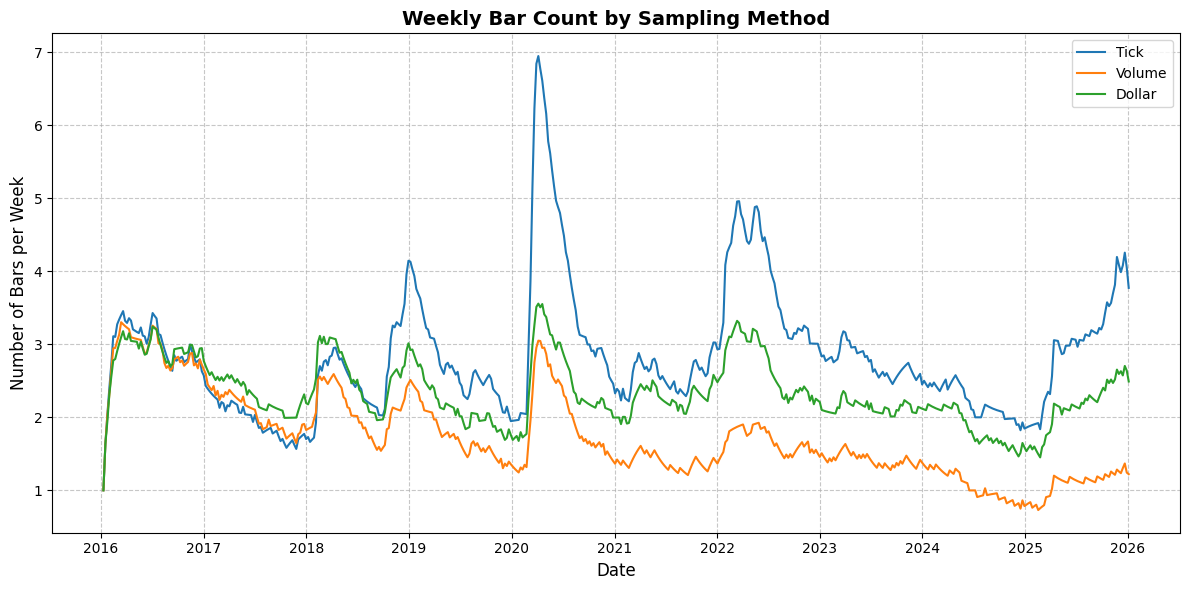

Stability Analysis (Coefficient of Variation):
            Mean       Std        CV
Dollar  2.367816  1.026874  0.433680
Volume  1.735632  1.034452  0.596009
Tick    2.890805  1.797191  0.621692


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_bar_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Calculates weekly bar counts, plots the time series, and computes the 
    Coefficient of Variation (CV) for stability analysis.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to its corresponding DataFrame of bars.
               DataFrames must have a DatetimeIndex.
    """
    weekly_counts = {}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # Resample to weekly frequency and count the number of bars
        counts = df.resample('W').size()
        weekly_counts[bar_type] = counts
        counts = counts.ewm(span=21, adjust=False).mean()  # Smooth the weekly counts for better 
        
        # Plotting
        ax.plot(counts.index, counts.values, label=bar_type, linewidth=1.5)
        
    ax.set_title("Weekly Bar Count by Sampling Method", fontsize=14, fontweight='bold')
    ax.set_ylabel("Number of Bars per Week", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()
    
    # Calculate and display the Coefficient of Variation
    cv_results = {}
    for bar_type, counts in weekly_counts.items():
        mean_count = counts.mean()
        std_count = counts.std()
        cv = std_count / mean_count if mean_count > 0 else np.nan
        cv_results[bar_type] = {'Mean': mean_count, 'Std': std_count, 'CV': cv}
        
    cv_df = pd.DataFrame(cv_results).T
    print("Stability Analysis (Coefficient of Variation):")
    print(cv_df.sort_values('CV'))
    
    return cv_df


# Example usage (assuming tick_df, vol_df, dollar_df exist):
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}
stats_df = analyze_bar_stability(bars_dict)

In [50]:
import pandas as pd
import numpy as np

def compute_serial_correlation(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the first-order serial correlation of log returns for given bar types.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to a DataFrame containing a 'Close' column.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # Compute log returns. 
        # Using log returns is non-negotiable for additive multi-period properties.
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # Calculate lag-1 autocorrelation
        rho_1 = returns.autocorr(lag=1)
        
        # Calculate absolute autocorrelation (critical for microstructure evaluation)
        abs_rho_1 = np.abs(rho_1)
        
        results[bar_type] = {
            'rho_1': rho_1, 
            '|rho_1|': abs_rho_1,
            'Sample_Size': len(returns)
        }
        
    results_df = pd.DataFrame(results).T
    # Sort by the lowest absolute serial correlation
    return results_df.sort_values('|rho_1|')

# Example Usage:
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars, 'Imbalance': imbalance_bars}
autocorr_stats = compute_serial_correlation(bars_dict)
print(autocorr_stats)



              rho_1   |rho_1|  Sample_Size
Dollar    -0.030275  0.030275       1235.0
Tick      -0.030291  0.030291       1508.0
Volume    -0.073462  0.073462        905.0
Imbalance -0.611559  0.611559          5.0


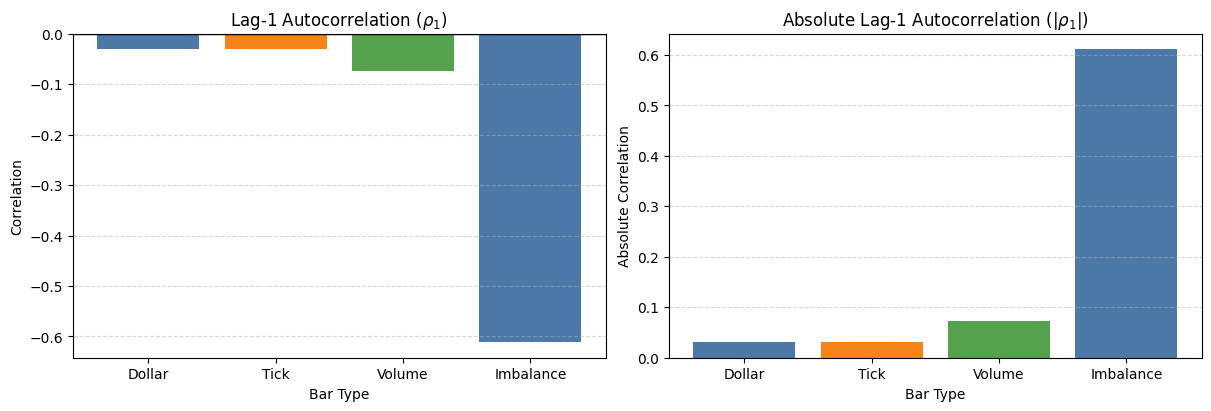

In [51]:
import matplotlib.pyplot as plt

# Plot serial correlation metrics by bar type
plot_df = autocorr_stats.copy()
plot_df.index = plot_df.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Signed lag-1 autocorrelation
axes[0].bar(plot_df.index, plot_df['rho_1'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Lag-1 Autocorrelation ($\\rho_1$)')
axes[0].set_ylabel('Correlation')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Absolute lag-1 autocorrelation (lower is better for microstructure noise)
axes[1].bar(plot_df.index, plot_df['|rho_1|'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Absolute Lag-1 Autocorrelation ($|\\rho_1|$)')
axes[1].set_ylabel('Absolute Correlation')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Bar Type')

plt.show()

Let $r_{i,m}$ be the log return of the $i$-th bar in month $m$, where $i \in [1, N_m]$.The sample variance for month $m$ is:$$V_m = \frac{1}{N_m - 1} \sum_{i=1}^{N_m} (r_{i,m} - \bar{r}_m)^2$$You are asking for the variance of this sequence of monthly variances, over $M$ total months:$$\text{Var}(V) = \frac{1}{M - 1} \sum_{m=1}^M (V_m - \bar{V})^2$$To correct your methodology, we must compute the relative stability:$$CV(V) = \frac{\sqrt{\text{Var}(V)}}{\bar{V}}$$A lower $CV(V)$ indicates that the sampling method successfully recovers a homoskedastic process across shifting market regimes
Why do dollar bars minimize $CV(V)$? The answer lies in the theory of subordinated stochastic processes, originally proposed by Clark (1973) and Mandelbrot.Financial prices do not evolve in chronological time $t$; they evolve in "transaction time" or "information time" $\tau$. If you model the log price $P(t)$ as a Brownian motion driven by an operational time variable $\tau(t)$, then chronological returns are conditionally normal but unconditionally leptokurtic (fat-tailed) because the variance is a random variable dictated by the trading rate.$$r_t \sim \mathcal{N}(0, \sigma^2 \Delta \tau_t)$$By sampling the market using dollar bars, you are forcing $\Delta \tau_t$ to be approximately constant. You are directly targeting the unobservable information arrival rate by using capital commitment as its proxy. If $\Delta \tau_t$ is rendered constant across months, the resulting return distribution $\mathcal{N}(0, \sigma^2 \Delta \tau)$ approaches true homoskedasticity, minimizing the variation of the monthly variances.

In [52]:
import pandas as pd
import numpy as np

def analyze_variance_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Partitions bar series into monthly subsets, computes the variance of returns 
    for each month, and evaluates the stability of those variances.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # 2. Partition into monthly subsets and compute variance
        # pd.Grouper is highly efficient for DatetimeIndex partitioning
        monthly_variances = returns.groupby(pd.Grouper(freq='ME')).var()
        
        # Drop months with insufficient data (e.g., NaN variances due to N=1)
        monthly_variances = monthly_variances.dropna()
        
        # 3. Compute statistics on the variances
        var_of_vars = monthly_variances.var()
        mean_var = monthly_variances.mean()
        
        # Dimensionless stability metric
        cv_of_vars = np.sqrt(var_of_vars) / mean_var if mean_var > 0 else np.nan
        
        results[bar_type] = {
            'Mean_Monthly_Variance': mean_var,
            'Variance_of_Variances': var_of_vars,
            'CV_of_Variances': cv_of_vars
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by the dimensionally correct metric, not the raw variance of variances
    return results_df.sort_values('CV_of_Variances')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
stability_stats = analyze_variance_stability(bars_dict)
print(stability_stats)

           Mean_Monthly_Variance  Variance_of_Variances  CV_of_Variances
Tick                    0.000155           1.977717e-08         0.905870
Volume                  0.000306           1.428893e-07         1.235101
Dollar                  0.000212           6.932773e-08         1.240056
Imbalance               0.000134                    NaN              NaN


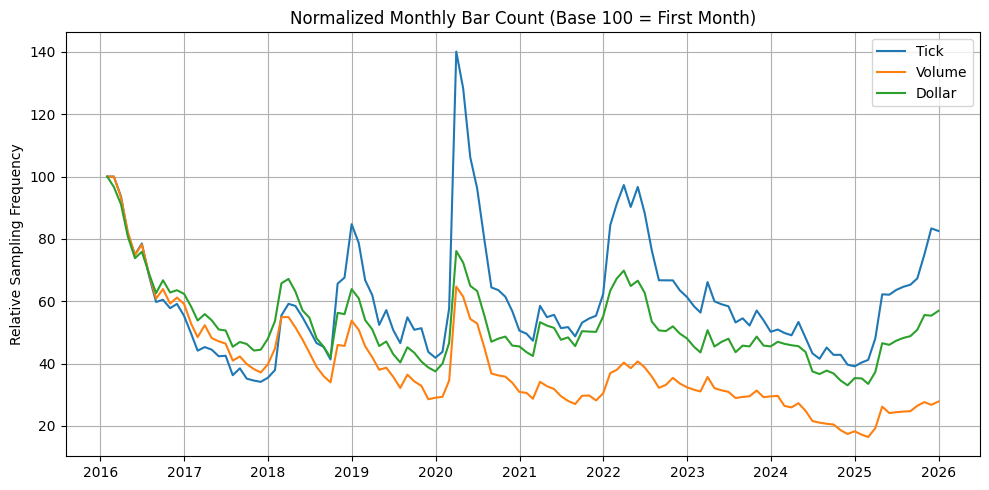

In [53]:
import matplotlib.pyplot as plt

def audit_sampling_heteroskedasticity(bars_dict: dict):
    """
    Plots the monthly bar counts. 
    If Dollar bars show a massive secular trend (up or down) compared to Tick/Volume,
    your threshold calibration is invalid.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for bar_type, df in bars_dict.items():
        # Count number of bars per month
        monthly_counts = df.resample('ME').size()  # Smooth the monthly counts for better visualization
        monthly_counts = monthly_counts.ewm(span=5, adjust=False).mean()

        # Normalize to base 100 for direct comparison of drift
        normalized_counts = (monthly_counts / monthly_counts.iloc[0]) * 100
        
        ax.plot(normalized_counts.index, normalized_counts.values, label=bar_type)
        
    ax.set_title("Normalized Monthly Bar Count (Base 100 = First Month)")
    ax.set_ylabel("Relative Sampling Frequency")
    ax.legend()
    fig.tight_layout()
    plt.grid(True)
    plt.show()

# Run this:
audit_sampling_heteroskedasticity({'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars})

The Jarque-Bera test measures the goodness-of-fit of sample data to a normal distribution, based specifically on the sample skewness ($S$) and kurtosis ($K$). The test statistic is defined as:$$JB = \frac{n}{6} \left( S^2 + \frac{(K-3)^2}{4} \right)$$Under the null hypothesis that the data is normally distributed, the $JB$ statistic follows a Chi-squared distribution with two degrees of freedom ($\chi^2_2$).Chronological financial returns exhibit massive excess kurtosis ($K \gg 3$). They are leptokurtic because information arrives in clusters, causing volatility to scale non-linearly with clock time. By sampling in "information time" using volume or dollar bars, you are attempting to strip out the stochastic variance of the sampling interval itself (the subordinated stochastic process).Because dollar bars best proxy the true arrival of macroeconomic risk transfer, they suppress the excess kurtosis far more effectively than tick or volume bars, mathematically forcing the $JB$ statistic down.

In [54]:
import pandas as pd
import numpy as np
from scipy import stats

def compute_normality_tests(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the Jarque-Bera test statistic for log returns of given bar types.
    WARNING: This comparison is mathematically invalid if lengths of returns (n) differ significantly.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        n = len(returns)
        
        # 2. Compute Skewness and Kurtosis (Fisher definition where Normal Kurtosis = 0)
        skewness = stats.skew(returns)
        # scipy.stats.kurtosis computes EXCESS kurtosis by default (K-3)
        excess_kurtosis = stats.kurtosis(returns, fisher=True) 
        
        # 3. Compute Jarque-Bera
        jb_stat, p_value = stats.jarque_bera(returns)
        
        results[bar_type] = {
            'N': n,
            'Skewness': skewness,
            'Excess_Kurtosis': excess_kurtosis,
            'JB_Statistic': jb_stat,
            'p_value': p_value
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by lowest JB Statistic
    return results_df.sort_values('JB_Statistic')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
jb_stats = compute_normality_tests(bars_dict)
print(jb_stats)

                N  Skewness  Excess_Kurtosis  JB_Statistic        p_value
Imbalance     5.0  1.379579         0.091870      1.587791   4.520802e-01
Tick       1508.0 -0.232237         2.273273    338.263628   3.523598e-74
Volume      905.0 -0.478400         3.256178    434.330724   4.856033e-95
Dollar     1235.0 -0.198230         3.269854    558.278005  5.908424e-122


To construct Imbalance Bars, we must first classify the aggressor side of every trade using the Tick Rule.Let $p_i$ be the price of the $i$-th tick. The tick sign $b_i \in \{-1, 1\}$ is defined recursively:$$b_i = \begin{cases} 
1 & \text{if } \Delta p_i > 0 \\
-1 & \text{if } \Delta p_i < 0 \\
b_{i-1} & \text{if } \Delta p_i = 0 
\end{cases}$$Standard Dollar Bars accumulate the absolute capital exchanged:$$D_k = \sum_{i=1}^k p_i v_i$$A bar is formed when $D_k \ge \theta_D$. Because it is strictly symmetric, $D_k$ grows regardless of whether the flow is buy-driven or sell-driven.Dollar Imbalance Bars accumulate the signed capital exchanged:$$\Theta_k = \sum_{i=1}^k b_i p_i v_i$$A bar is formed when the absolute imbalance exceeds an expected threshold: $|\Theta_k| \ge \tau_D$.

Standard dollar bars are a variance-stabilizing transformation. They sample the market when a fixed amount of risk has changed hands, neutralizing the bid-ask bounce and the clustering of volatility. Because they group buys and sells together indifferently, the resulting return sequence closely approximates a random walk ($\rho_1 \approx 0$).Dollar Imbalance Bars are a feature-extraction transformation. They lie dormant during periods of balanced two-way flow (e.g., market makers trading with retail noise). They trigger rapidly when informed liquidity takers aggressively sweep the book in one direction.If a fundamental fund is executing a massive TWAP buy order over two hours, the standard dollar bars will trigger at a steady rate. The Dollar Imbalance Bars, however, will fire continuously in rapid succession as the buy-side accumulator $\Theta_k$ quickly breaches $\tau_D$ repeatedly.Because these rapid-fire bars are strictly isolating the directional momentum of the institutional parent order, the return from $T_k$ to $T_{k+1}$ will generally have the same sign as the return from $T_{k+1}$ to $T_{k+2}$. This inherently induces strong positive serial correlation in the DIB return series during trending regimes.